In [207]:
# Import library
import warnings
warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from typing import Dict, Tuple

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Data Loading and Processing

We drop the duplicated variable including month, day_of_week_cat, park_cat, visitors_capped, log1p_visitors. 

In [218]:
# Read dataset
dat = pd.read_csv("demand_data.csv")

In [220]:
dat.columns

Index(['visit_date', 'park', 'visitors', 'calendar_date', 'holiday_name', 'is_school_holiday', 'is_public_holiday', 'is_holiday', 'is_closed_day', 'is_long_weekend', 'is_ramadan', 'month_of_year', 'day_of_week',
       'day_of_year', 'sin_annual', 'cos_annual', 'month', 'has_nof_lagoon', 'month_of_year_cat', 'day_of_week_cat', 'park_cat', 'visitors_capped', 'log1p_visitors'],
      dtype='str')

In [196]:
# Let's drop the duplicated variable
# This includes month, day_of_week_cat, park_cat, visitors_capped, log1p_visitors

# List of columns to remove
cols_to_drop = [
    "month", 
    "day_of_week_cat", 
    "park_cat", 
    "visitors_capped", 
    "log1p_visitors",
    "month_of_year_cat"
]

# Drop columns only if they currently exist in the dataframe
dat = dat.drop(columns=[c for c in cols_to_drop if c in dat.columns])

# Verify the changes
print(f"Remaining columns: {dat.columns.tolist()}")
dat.head()

Remaining columns: ['visit_date', 'park', 'visitors', 'calendar_date', 'holiday_name', 'is_school_holiday', 'is_public_holiday', 'is_holiday', 'is_closed_day', 'is_long_weekend', 'is_ramadan', 'month_of_year', 'day_of_week', 'day_of_year', 'sin_annual', 'cos_annual', 'has_nof_lagoon']


,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0
1,2024-01-02,Lost World,457,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0
2,2024-01-03,Lost World,1124,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0
3,2024-01-04,Lost World,1255,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0
4,2024-01-05,Lost World,998,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0


# Metrics Function

**Why we should focus on WMAPE (Weighted Mean Absolute Percentage Error) compared to R^2?**

For the purpose of operational forecasting, we prioritize Weighted Mean Absolute Percentage Error (WMAPE) over $R^2$ as our primary performance metric because it directly aligns with business decision-making and resource allocation. 

While $R^2$ is a statistical measure of variance that is heavily penalized by the extreme, non-linear attendance spikes typical of holiday seasons, WMAPE provides a clear, interpretable percentage representing our average forecast error. 

Because WMAPE weights errors relative to the actual visitor volume, it allows us to quantify our operational margin of error in practical terms—providing management with a reliable answer to "how inaccurate is our staffing plan?" rather than an abstract statistical coefficient that can be disproportionately skewed by the very events we are trying to predict.

WMAPE calculates the total error relative to the total volume. This ensures that your accuracy on high-traffic days (like a holiday) matters more to the metric than your accuracy on a slow Tuesday.

Eg, WMAPE = 10%, it means on average every day there is a 10% error rate in prediction error for the visitors count, hence we should prepare a buffer of 10% in case there is a sudden rise or drop in the number of visitors. In addition, we specify in the previous working file that our goal is to achieve only 10% of WMAPE. 

In [197]:
# Define the get metrics function
# Note the benchmark r2 is 0.1424

def get_metrics(y_true, y_pred, model_fit=None):
    """Evaluation suite that handles both OLS and tree-based models."""
    denom = np.sum(np.abs(y_true))
    wmape = np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan
    
    # Calculate Adj R2 ONLY if a valid model_fit object with the attribute exists
    adj_r2 = np.nan
    if model_fit is not None and hasattr(model_fit, 'rsquared_adj'):
        adj_r2 = model_fit.rsquared_adj
        
    return {
        "wmape": wmape,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "bias": np.mean(y_pred - y_true),
        "adj_r2": adj_r2
    }

# Model Fitting

In [198]:
# Training random forest for two separate parks

# 2. Setup Feature Groups
cat_features_no_park = ['day_of_week', 'month_of_year']
numeric_features = [
    'is_holiday', 'is_closed_day', 'is_long_weekend', 
    'is_ramadan', 'sin_annual', 'cos_annual', 'has_nof_lagoon'
]

**Feature Documentation: days_to_holiday**

1. What is this variable?
- The days_to_holiday variable is a temporal proximity feature (often called a "countdown" feature). For any given date in the dataset, it calculates the number of days remaining until the next upcoming public holiday.
- If today is a holiday, the value is 0.
- If the next holiday is 1 day away (e.g., the day before a public holiday), the value is 1.
- If the next holiday is one week away, the value is 7.

2. Why are we adding this?
Standard holiday flags (0 or 1) treat holidays as "point events"—the model only learns to adjust its prediction on the exact day the holiday occurs. However, real-world human behavior is not a "step function"; it is a gradual process. Adding this variable allows the model to capture the "Anticipation Effect":

- Behavioral Buildup: Theme park attendance often begins to climb in the days leading up to a long weekend or festive season as families finalize travel plans or take advantage of pre-holiday promotions.
- Marketing Impact: Theme parks frequently run "pre-holiday" sales or events that drive traffic before the actual holiday dates.
- Modeling "The Slope": By providing this countdown, we are essentially turning a "cliff" (the sudden spike of a holiday) into a "ramp." This gives the algorithm a gradient to follow, making it easier for models like XGBoost to learn the buildup of the attendance spike rather than just reacting to the peak.

3. How to interpret it?
The feature should be interpreted as a distance-to-event metric:

Decreasing values indicate an approaching spike: As the value drops from 7 down to 1, the model learns that we are entering a high-traffic window. This allows the model to "warm up" its predictions, correctly forecasting higher visitor numbers even before the holiday actually begins.

- The value of 0 is a specific state: A value of 0 indicates the peak event day, which the model correlates with maximum capacity constraints or peak operational demand.
- High values: Values far from 0 (e.g., 20+ days away) represent "baseline" periods where holiday behavior has little to no impact on current attendance.

In [199]:
# Add another indicator - how long it is till it is a holiday
# Create a "Days to next holiday" feature
# We assume you have a column 'is_holiday' (1 for holiday, 0 otherwise)

# 3. Feature Engineering for Holidays
dat = dat.sort_values(['park', 'visit_date'])

def get_days_to_holiday(group):
    group_dates = pd.to_datetime(group['visit_date'])
    holiday_dates = pd.to_datetime(group[group['is_holiday'] == 1]['visit_date'])
    if len(holiday_dates) == 0:
        return pd.Series([0] * len(group), index=group.index)
    return group_dates.apply(lambda d: (holiday_dates - d).dt.days.min())

dat['visit_date'] = pd.to_datetime(dat['visit_date'])
dat['is_holiday'] = dat['is_holiday'].astype(int)
dat['days_to_holiday'] = dat.groupby('park', group_keys=False).apply(get_days_to_holiday)

dat.head()

,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon,days_to_holiday
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0,0
1,2024-01-02,Lost World,457,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0,-1
2,2024-01-03,Lost World,1124,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0,-2
3,2024-01-04,Lost World,1255,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0,-3
4,2024-01-05,Lost World,998,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0,-4


**Feature Documentation: is_payday_window**

1. What is this variable?
The is_payday_window variable is a binary categorical feature (a "flag"). It identifies periods of time at the turn of the month—specifically from the 25th of the current month to the 3rd of the following month—which historically align with the salary cycle for most employees in the region.

- 1 (Active Window): Indicates the period immediately surrounding payday when consumers typically have the highest levels of disposable income.
- 0 (Mid-Month): Indicates the rest of the month, which is traditionally characterized by tighter discretionary budgets.

2. Why are we adding this?
Attendance at leisure venues like theme parks is considered discretionary spending. Consumer confidence and spending power are rarely linear; they fluctuate based on the availability of cash flow.
- Spending Cycle Correlation: By capturing the "payday effect," we allow the model to learn that there is an inherent economic rhythm to attendance. Families are mathematically more likely to book tickets, purchase park meals, and utilize park services when their monthly income has just been deposited.
- Accounting for Economic Rhythm: Unlike public holidays which are "spikes," this feature captures a "pulse." It helps the model differentiate between a random Tuesday and a "Payday Tuesday," where spending power is higher.

3. How to interpret it?
The feature acts as a proxy for consumer liquidity:
- A value of 1: Correlates with higher attendance expectations. You should expect this feature to have a positive impact on your target visitor count in the model’s importance analysis.
- A value of 0: Serves as the "baseline" or "mid-month squeeze," where attendance might naturally dip as households prioritize essential expenses over leisure activities.
- Predictive Power: If this feature shows high importance, it proves that your visitors are economically sensitive, providing a valuable insight for the park management regarding when to schedule marketing pushes or ticket promotions.

In [200]:
# Create a "Days since salary" feature
# We check the day of the month. If it's 25-30, it's high spend. 
# We can represent this as a proximity feature to the 25th.
dat['day_of_month'] = dat['visit_date'].dt.day
dat['is_payday_window'] = ((dat['day_of_month'] >= 25) | (dat['day_of_month'] <= 3)).astype(int)

dat.head()
dat.shape

(1273, 20)

**Feature Documentation: holiday_streak**

1. What is this variable?
The holiday_streak variable is a sequential counter that tracks the position of the current date within a continuous block of holidays.
- 0 (Non-Holiday): Indicates a standard operating day.
- 1 (First Day): Indicates the start of a holiday period.
- 2, 3, 4, ... (Subsequent Days): Indicates the progression of the holiday. For example, a 3-day long weekend will result in values of 1, 2, and 3 respectively across those dates.

2. Why are we adding this?
Public holidays are rarely uniform in their impact on attendance. A simple "Yes/No" flag treats all holidays as identical, but human behavior changes significantly as a holiday progresses:

- The "Travel & Arrival" Effect: Day 1 of a long holiday often has different attendance patterns (e.g., people traveling or settling in) compared to the peak middle days.
- The "Holiday Fatigue" Effect: As a holiday streak lengthens, attendance often tapers off toward the final day as visitors prepare to return to work or school.
- Capture Duration Dynamically: This feature automatically differentiates between a single-day public holiday (which only ever reaches a value of 1) and a multi-day school holiday break (which can reach higher values). It allows the model to learn that "Day 2 of 4" of a holiday has a distinct attendance profile compared to "Day 1 of 1."

3. How to interpret it?
The feature acts as a holiday-aging metric:

- Low values (1): Represent the initiation of the holiday spike. You might see this correlate with initial surges in traffic.
- Higher values (e.g., 3+): Represent the mature phase of a holiday. If the model finds this feature important, it suggests that the "mid-holiday" period is structurally different from the "start-holiday" period.
- Zero values: Serve as the baseline for non-holiday days.

In [201]:
# 1. Sort the entire dataset first
dat = dat.sort_values(['park', 'visit_date'])

# 2. Identify where a "streak" changes
# A streak changes if:
# - The holiday status changes (0 to 1 or 1 to 0)
# - OR the park changes (new park = new streak)
change_condition = (dat['is_holiday'] != dat['is_holiday'].shift()) | \
                   (dat['park'] != dat['park'].shift())

# 3. Create a block ID using cumulative sum
dat['holiday_block'] = change_condition.cumsum()

# 4. Calculate the streak within each block
# We group by park AND the block ID to ensure we never cross boundaries
dat['holiday_streak'] = dat.groupby(['park', 'holiday_block'])['is_holiday'].cumsum() * dat['is_holiday']

# 5. Clean up helper columns
dat = dat.drop(columns=['holiday_block'])

print("Columns present:", dat.columns.tolist())
dat.head()

Columns present: ['visit_date', 'park', 'visitors', 'calendar_date', 'holiday_name', 'is_school_holiday', 'is_public_holiday', 'is_holiday', 'is_closed_day', 'is_long_weekend', 'is_ramadan', 'month_of_year', 'day_of_week', 'day_of_year', 'sin_annual', 'cos_annual', 'has_nof_lagoon', 'days_to_holiday', 'day_of_month', 'is_payday_window', 'holiday_streak']


,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon,days_to_holiday,day_of_month,is_payday_window,holiday_streak
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0,0,1,1,1
1,2024-01-02,Lost World,457,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0,-1,2,1,0
2,2024-01-03,Lost World,1124,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0,-2,3,1,0
3,2024-01-04,Lost World,1255,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0,-3,4,0,0
4,2024-01-05,Lost World,998,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0,-4,5,0,0


**Feature Documentation: Lag & Trend Features (lag_1, lag_7, rolling_mean_7)**

1. What are these variables?
These are Autoregressive Features. They "give the model a memory" by explicitly feeding past attendance data into the current prediction:
- lag_1: The visitor count from exactly 1 day ago (Short-term momentum).
- lag_7: The visitor count from exactly 7 days ago (Weekly seasonality).
- rolling_mean_7: The average visitor count over the previous 7 days (Underlying trend).

2. Why are we adding them?
Theme park attendance is not a random event; it has inertia and seasonality. A model that looks only at "today" is flying blind. By adding these features, we transform the model from a simple "seasonal guesser" into a "trend follower":

- Capturing Momentum (lag_1): If a park was busy yesterday, it is highly likely to be busy today. This feature allows the model to react to unexpected surges or drops immediately.
- Capturing Weekly Cycles (lag_7): Weekend demand is predictable. If last Saturday was a peak, this Saturday is mathematically more likely to be a peak as well. This feature anchors the prediction to the weekly calendar.
- Smoothing Noise (rolling_mean_7): Daily attendance is often "noisy" (a single day of rain can cause a temporary dip). The 7-day average strips away that noise to reveal the true underlying trend—telling the model whether we are entering a "busy season" or a "quiet season."

3. How to interpret them?
- Positive Coefficients/Importance: If lag_1 or lag_7 appear as top drivers, it confirms that your visitors' behavior is highly predictable based on recent past patterns.
- Trend Shifts (rolling_mean_7): A rising rolling_mean_7 indicates the park is entering an upward growth trend. If the model sees this rising, it will naturally start predicting higher values for the days ahead, effectively "learning" the start of a peak season.

Imputation Note: For the very first week of the dataset, these values were filled with 0. This is a technical standard to ensure the model can still train on the early data without crashing, though the model's accuracy on the first 7 days of the dataset should be considered a "burn-in" period.

In [202]:
# Create Lag features
dat = dat.sort_values(['park', 'visit_date'])
dat['lag_1'] = dat.groupby('park')['visitors'].shift(1)
dat['lag_7'] = dat.groupby('park')['visitors'].shift(7)

# Create a Rolling Average
dat['rolling_mean_7'] = dat.groupby('park')['visitors'].transform(lambda x: x.rolling(window=7).mean())

# --- INSTEAD OF DROPPING, FILL THE GAPS ---
# Fill the first 7 days of each park with the first available value (or 0)
dat['lag_1'] = dat['lag_1'].fillna(0)
dat['lag_7'] = dat['lag_7'].fillna(0)
dat['rolling_mean_7'] = dat['rolling_mean_7'].fillna(0)

## Random Forest

In [214]:
# 1. Define your feature groups clearly
# Ensure 'base' contains your initial set, and 'advanced' contains all additions
features_base = cat_features_no_park + numeric_features
features_advanced = cat_features_no_park + numeric_features + ['days_to_holiday', 'is_payday_window', 'holiday_streak', 'lag_1', 'lag_7', 'rolling_mean_7']

# 2. Store them in a dictionary
model_configs = {
    "Base Model": features_base,
    "Advanced Model": features_advanced
}

# 3. Training Loop
months = sorted(dat["visit_date"].dt.to_period("M").unique())

# Initialize these BEFORE the loop
final_importances = {}
all_predictions_list = []
results = []

for config_name, feature_list in model_configs.items():
    print(f"Training {config_name}...")
    
    # Define preprocessor dynamically for this specific feature set
    # Using 'passthrough' for numeric and OHE for categorical
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_no_park)
        ],
        remainder='passthrough'
    )
    
    for i in range(6, len(months) - 1):
        train_end = months[i].to_timestamp(how='end')
        train_df_full = dat[dat["visit_date"] <= train_end]
        test_df_full = dat[dat["visit_date"].dt.to_period("M") == months[i+1]]
        
        for p in parks:
            train_df = train_df_full[train_df_full['park'] == p]
            test_df = test_df_full[test_df_full['park'] == p]
            
            if len(train_df) == 0 or len(test_df) == 0:
                continue
                
            model = Pipeline([
                ('preprocessor', preprocessor),
                ('regressor', RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42))
            ])
            
            # 1. Train
            model.fit(train_df[feature_list], train_df[target])
            
            # --- ADD THIS: Extract Data for Importances ---
            # Get the fitted steps from the pipeline
            fitted_preprocessor = model.named_steps['preprocessor']
            fitted_regressor = model.named_steps['regressor']
            
            # Extract feature names and importances
            feature_names = fitted_preprocessor.get_feature_names_out(feature_list)
            importances = fitted_regressor.feature_importances_
            
            # Capture importances with a unique key for each model+park combo
            # We store the latest one (or average them if you prefer, but storing the latest is fine for analysis)
            final_importances[(config_name, p)] = pd.DataFrame({
                'Feature': feature_names, 
                'Importance': importances
            }).sort_values(by='Importance', ascending=False)
            # ---------------------------------------------
            
            # 2. Predict
            pred = np.clip(model.predict(test_df[feature_list]), 0, None)

            # Capture predictions for plotting
            p_df = test_df[['park', 'visit_date', target]].copy()
            p_df['prediction'] = pred
            p_df['model_type'] = config_name
            p_df['test_month'] = months[i+1]
            all_predictions_list.append(p_df)
            
            # 3. Evaluate
            metrics = get_metrics(test_df[target], pred, None)
            metrics["park"] = p
            metrics["model_type"] = config_name
            results.append(metrics)

# 4. View Results per Park AND Model Type
results_df = pd.DataFrame(results)
print("\n=== Comparative Performance (Base vs Advanced) ===")
# Group by both model type and park for a clear table

# Calculate your custom metrics
summary = results_df.groupby(["model_type", "park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),      # Measure of stability
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),       # Measure of over/under forecasting
    n_folds=("wmape", "count")       # Number of months evaluated
).round(4)

print("\n=== Comprehensive Model Comparison ===")
print(summary)

Training Base Model...
Training Advanced Model...

=== Comparative Performance (Base vs Advanced) ===

=== Comprehensive Model Comparison ===
                              avg_wmape  std_wmape    avg_mae  avg_bias  n_folds
model_type     park                                                             
Advanced Model Lost World        0.3301     0.1538   597.4967  181.1149       15
               Sunway Lagoon     0.3650     0.1380   955.2047  228.7324       15
Base Model     Lost World        0.4324     0.2690   747.8867  219.3829       15
               Sunway Lagoon     0.4051     0.1536  1056.1801  353.7326       15


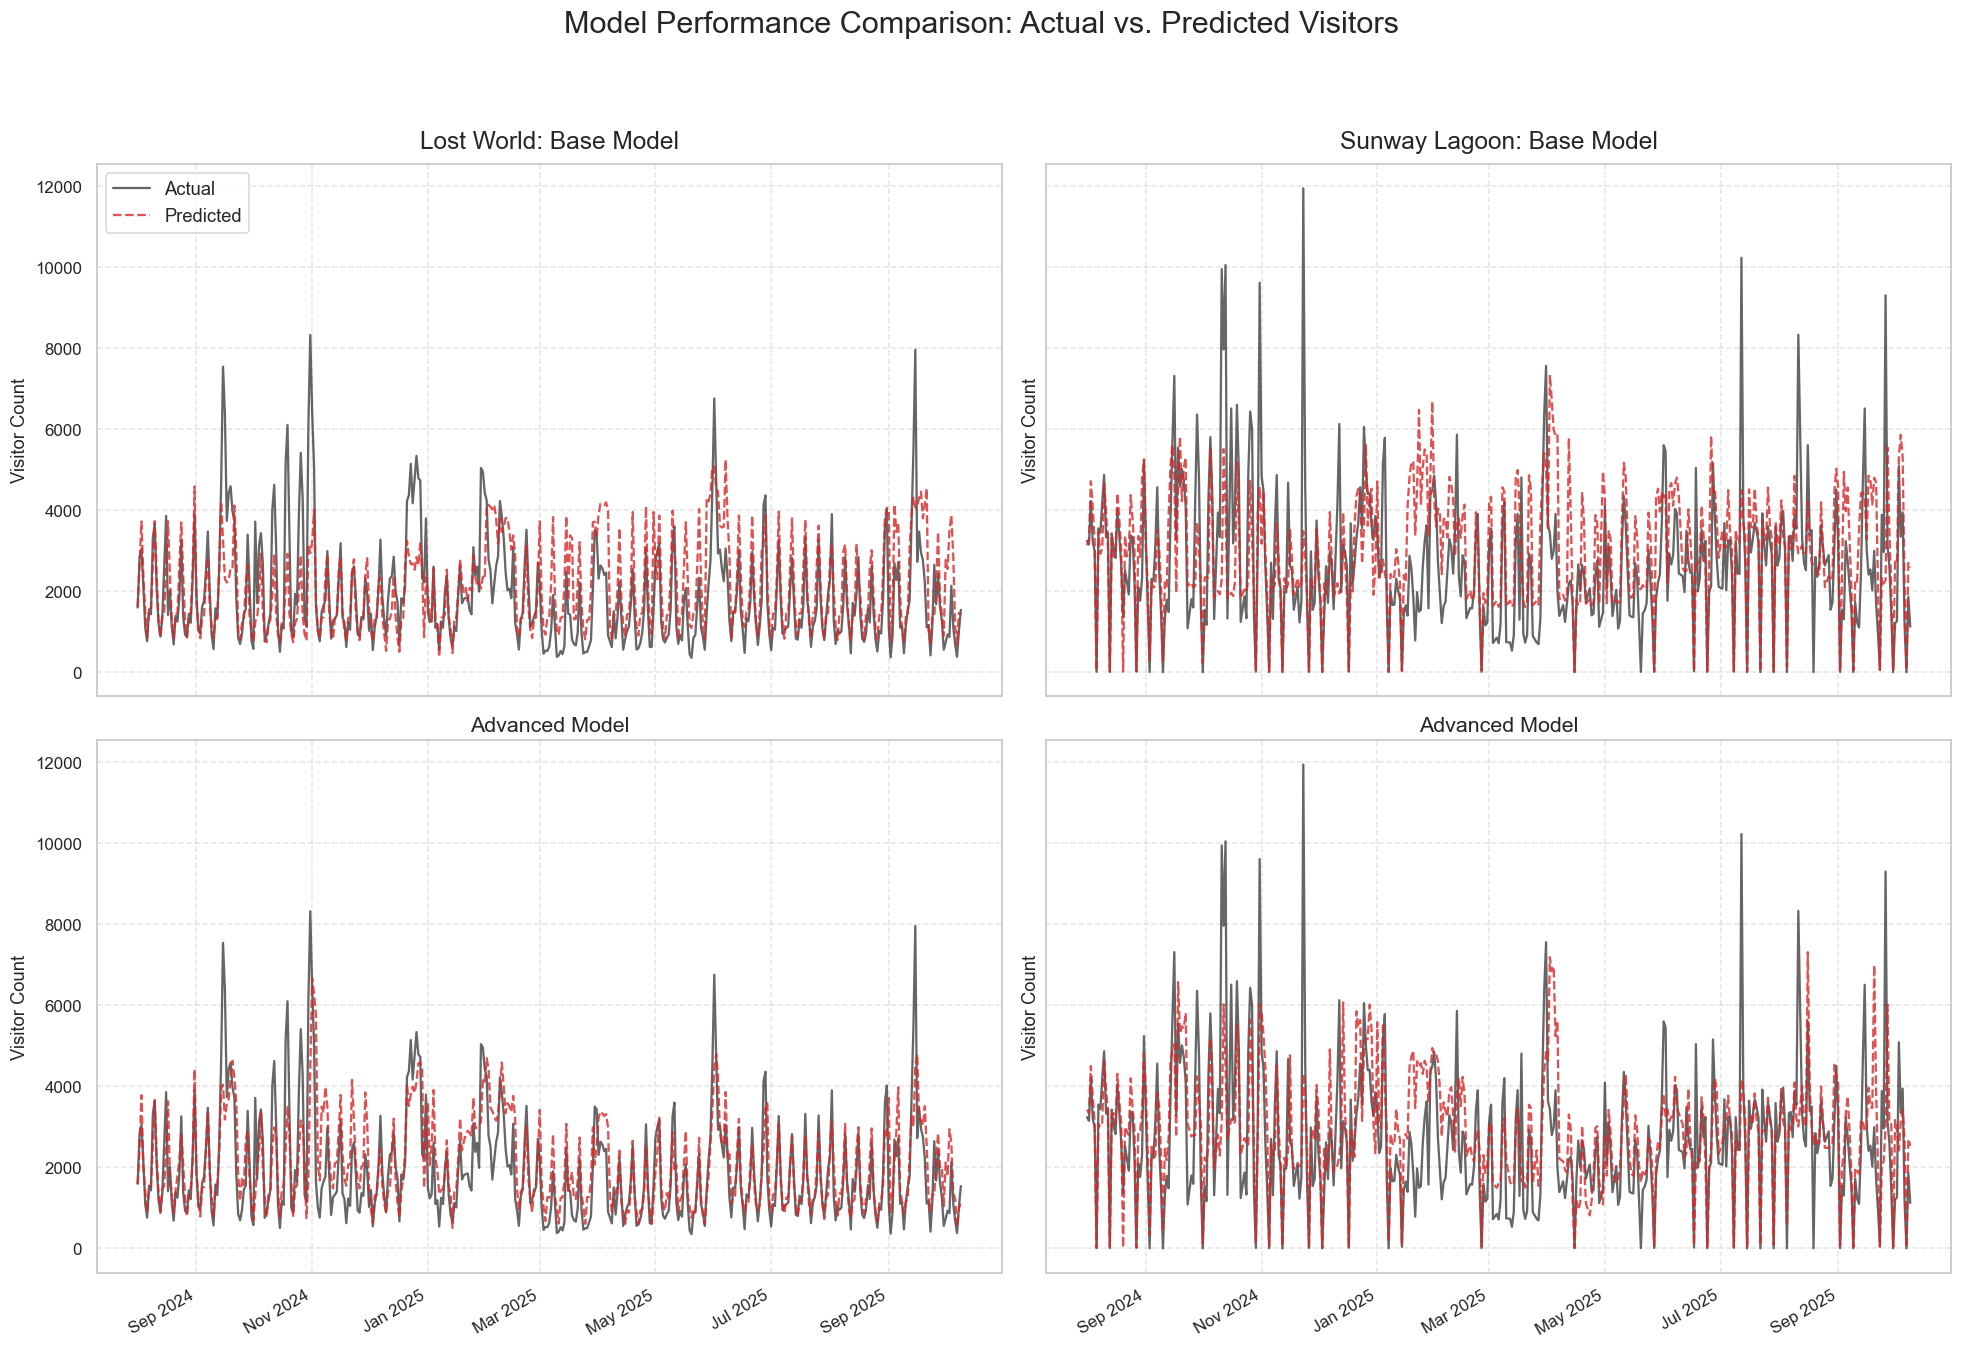

In [208]:
# Visualize the prediction VS actual result
# 1. Combine all predictions into one DataFrame
all_predictions_df = pd.concat(all_predictions_list)
all_predictions_df['visit_date'] = pd.to_datetime(all_predictions_df['visit_date'])

# 2. Setup the 2x2 Grid
# We define our iterators: Model Types and Parks
model_types = ['Base Model', 'Advanced Model']
parks = all_predictions_df['park'].unique()

# Create subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey='row')
fig.suptitle('Model Performance Comparison: Actual vs. Predicted Visitors', fontsize=20, y=1.02)

# 3. Iterate through Grid Positions
plot_count = 0
for row, m_type in enumerate(model_types):
    for col, p_name in enumerate(parks):
        ax = axes[row, col]
        
        # Filter data for this specific plot (this park + this model)
        plot_data = all_predictions_df[
            (all_predictions_df['model_type'] == m_type) & 
            (all_predictions_df['park'] == p_name)
        ].sort_values('visit_date')
        
        # Plot Actual vs. Predicted
        ax.plot(plot_data['visit_date'], plot_data[target], label='Actual', color='black', alpha=0.6, linewidth=1.5)
        ax.plot(plot_data['visit_date'], plot_data['prediction'], label='Predicted', color='tab:red', linestyle='--', alpha=0.8, linewidth=1.5)
        
        # Chart Formatting
        if row == 0:
            ax.set_title(f'{p_name}: {m_type}', fontsize=16, pad=10)
        else:
            ax.set_title(f'{m_type}', fontsize=14)
            
        ax.set_ylabel('Visitor Count', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Only show legend on the first plot to avoid clutter
        if plot_count == 0:
            ax.legend(fontsize=12, loc='upper left')
        
        plot_count += 1

# 4. Final Layout Adjustments
# Format the x-axis to show months clearly
for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # Tick every 2 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # Format: 'Jan 2024'
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right') # Rotate labels

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to fit main title
plt.show()

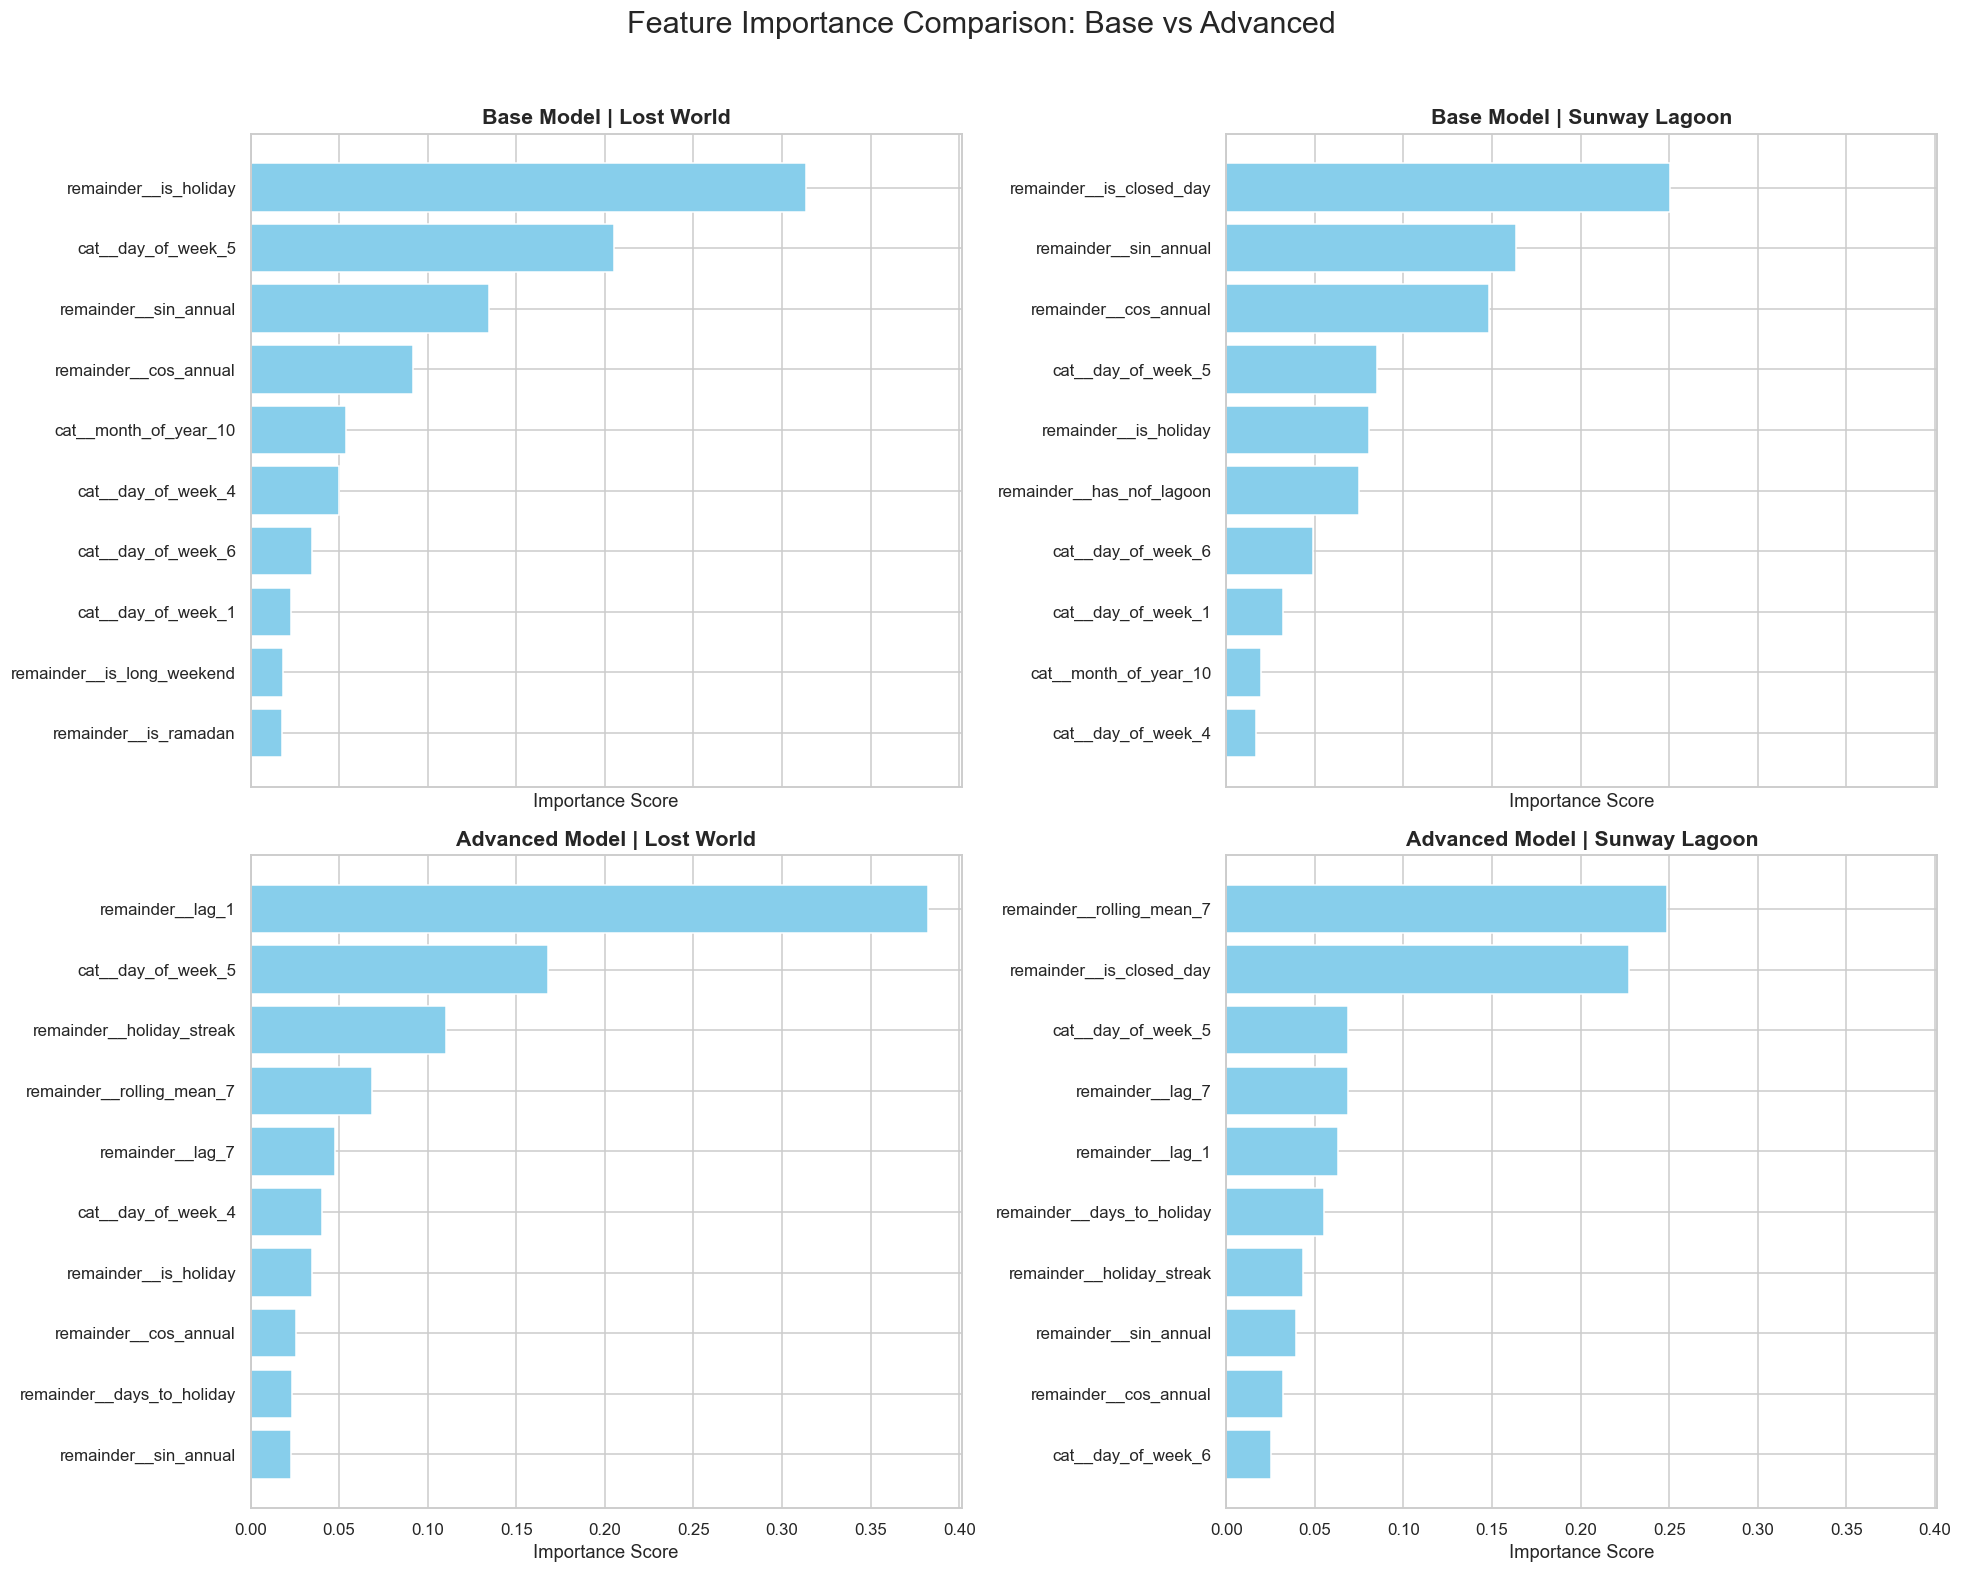

In [213]:
# Feature importance plot

# 1. Setup the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=True)
fig.suptitle('Feature Importance Comparison: Base vs Advanced', fontsize=20, y=1.02)

# Define the grid structure (Row 0 = Base, Row 1 = Advanced)
model_types = ['Base Model', 'Advanced Model']
parks = sorted(dat['park'].unique()) # Ensures order (e.g., Lost World, Sunway)

for row, m_type in enumerate(model_types):
    for col, p in enumerate(parks):
        ax = axes[row, col]
        
        # Get data from the dictionary
        key = (m_type, p)
        if key in final_importances:
            df = final_importances[key].head(10) # Top 10 features
            ax.barh(df['Feature'], df['Importance'], color='skyblue')
            ax.set_title(f"{m_type} | {p}", fontsize=14, fontweight='bold')
            ax.invert_yaxis()
            ax.set_xlabel("Importance Score")
        else:
            ax.text(0.5, 0.5, 'No data', ha='center')

plt.tight_layout()
plt.show()

## XGBoost

In [215]:
from xgboost import XGBRegressor

# 1. Define feature groups
# Ensure numeric_features_base contains your initial features
features_base = cat_features_no_park + numeric_features
features_advanced = cat_features_no_park + numeric_features + ['days_to_holiday', 'is_payday_window', 'holiday_streak', 'lag_1', 'lag_7', 'rolling_mean_7']

# 2. Store them in a dictionary
model_configs = {
    "Base Model": features_base,
    "Advanced Model": features_advanced
}

# 3. Initialize storage containers
results = []
final_importances = {}
all_predictions_list = []

# 4. Training Loop
months = sorted(dat["visit_date"].dt.to_period("M").unique())
parks = dat['park'].unique()

for config_name, feature_list in model_configs.items():
    print(f"Training {config_name} with XGBoost...")
    
    # Define preprocessor inside loop to reset state for each model config
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_no_park)
        ],
        remainder='passthrough'
    )
    
    for i in range(6, len(months) - 1):
        train_end = months[i].to_timestamp(how='end')
        train_df_full = dat[dat["visit_date"] <= train_end]
        test_df_full = dat[dat["visit_date"].dt.to_period("M") == months[i+1]]
        
        for p in parks:
            train_df = train_df_full[train_df_full['park'] == p]
            test_df = test_df_full[test_df_full['park'] == p]
            
            if len(train_df) == 0 or len(test_df) == 0:
                continue
                
            # Define Pipeline with XGBoost
            model = Pipeline([
                ('preprocessor', preprocessor),
                ('regressor', XGBRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    objective='reg:absoluteerror', 
                    random_state=42,
                    n_jobs=-1
                ))
            ])
            
            # Train
            model.fit(train_df[feature_list], train_df[target])
            
            # Capture Importances
            fitted_preprocessor = model.named_steps['preprocessor']
            fitted_regressor = model.named_steps['regressor']
            feature_names = fitted_preprocessor.get_feature_names_out(feature_list)
            importances = fitted_regressor.feature_importances_
            
            final_importances[(config_name, p)] = pd.DataFrame({
                'Feature': feature_names, 
                'Importance': importances
            }).sort_values(by='Importance', ascending=False)
            
            # Predict
            pred = np.clip(model.predict(test_df[feature_list]), 0, None)

            # Capture predictions for plotting later
            p_df = test_df[['park', 'visit_date', target]].copy()
            p_df['prediction'] = pred
            p_df['model_type'] = config_name
            p_df['test_month'] = months[i+1]
            all_predictions_list.append(p_df)
            
            # Evaluate
            metrics = get_metrics(test_df[target], pred, None)
            metrics["park"] = p
            metrics["model_type"] = config_name
            results.append(metrics)

# 5. Generate Summary Table
results_df = pd.DataFrame(results)
summary = results_df.groupby(["model_type", "park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Comprehensive Model Comparison (XGBoost) ===")
print(summary)

Training Base Model with XGBoost...
Training Advanced Model with XGBoost...

=== Comprehensive Model Comparison (XGBoost) ===
                              avg_wmape  std_wmape    avg_mae  avg_bias  n_folds
model_type     park                                                             
Advanced Model Lost World        0.3151     0.1262   576.9358  159.2993       15
               Sunway Lagoon     0.3381     0.1095   900.8623  137.7695       15
Base Model     Lost World        0.4396     0.2149   778.5666  190.3891       15
               Sunway Lagoon     0.4151     0.2220  1094.8796  251.6498       15


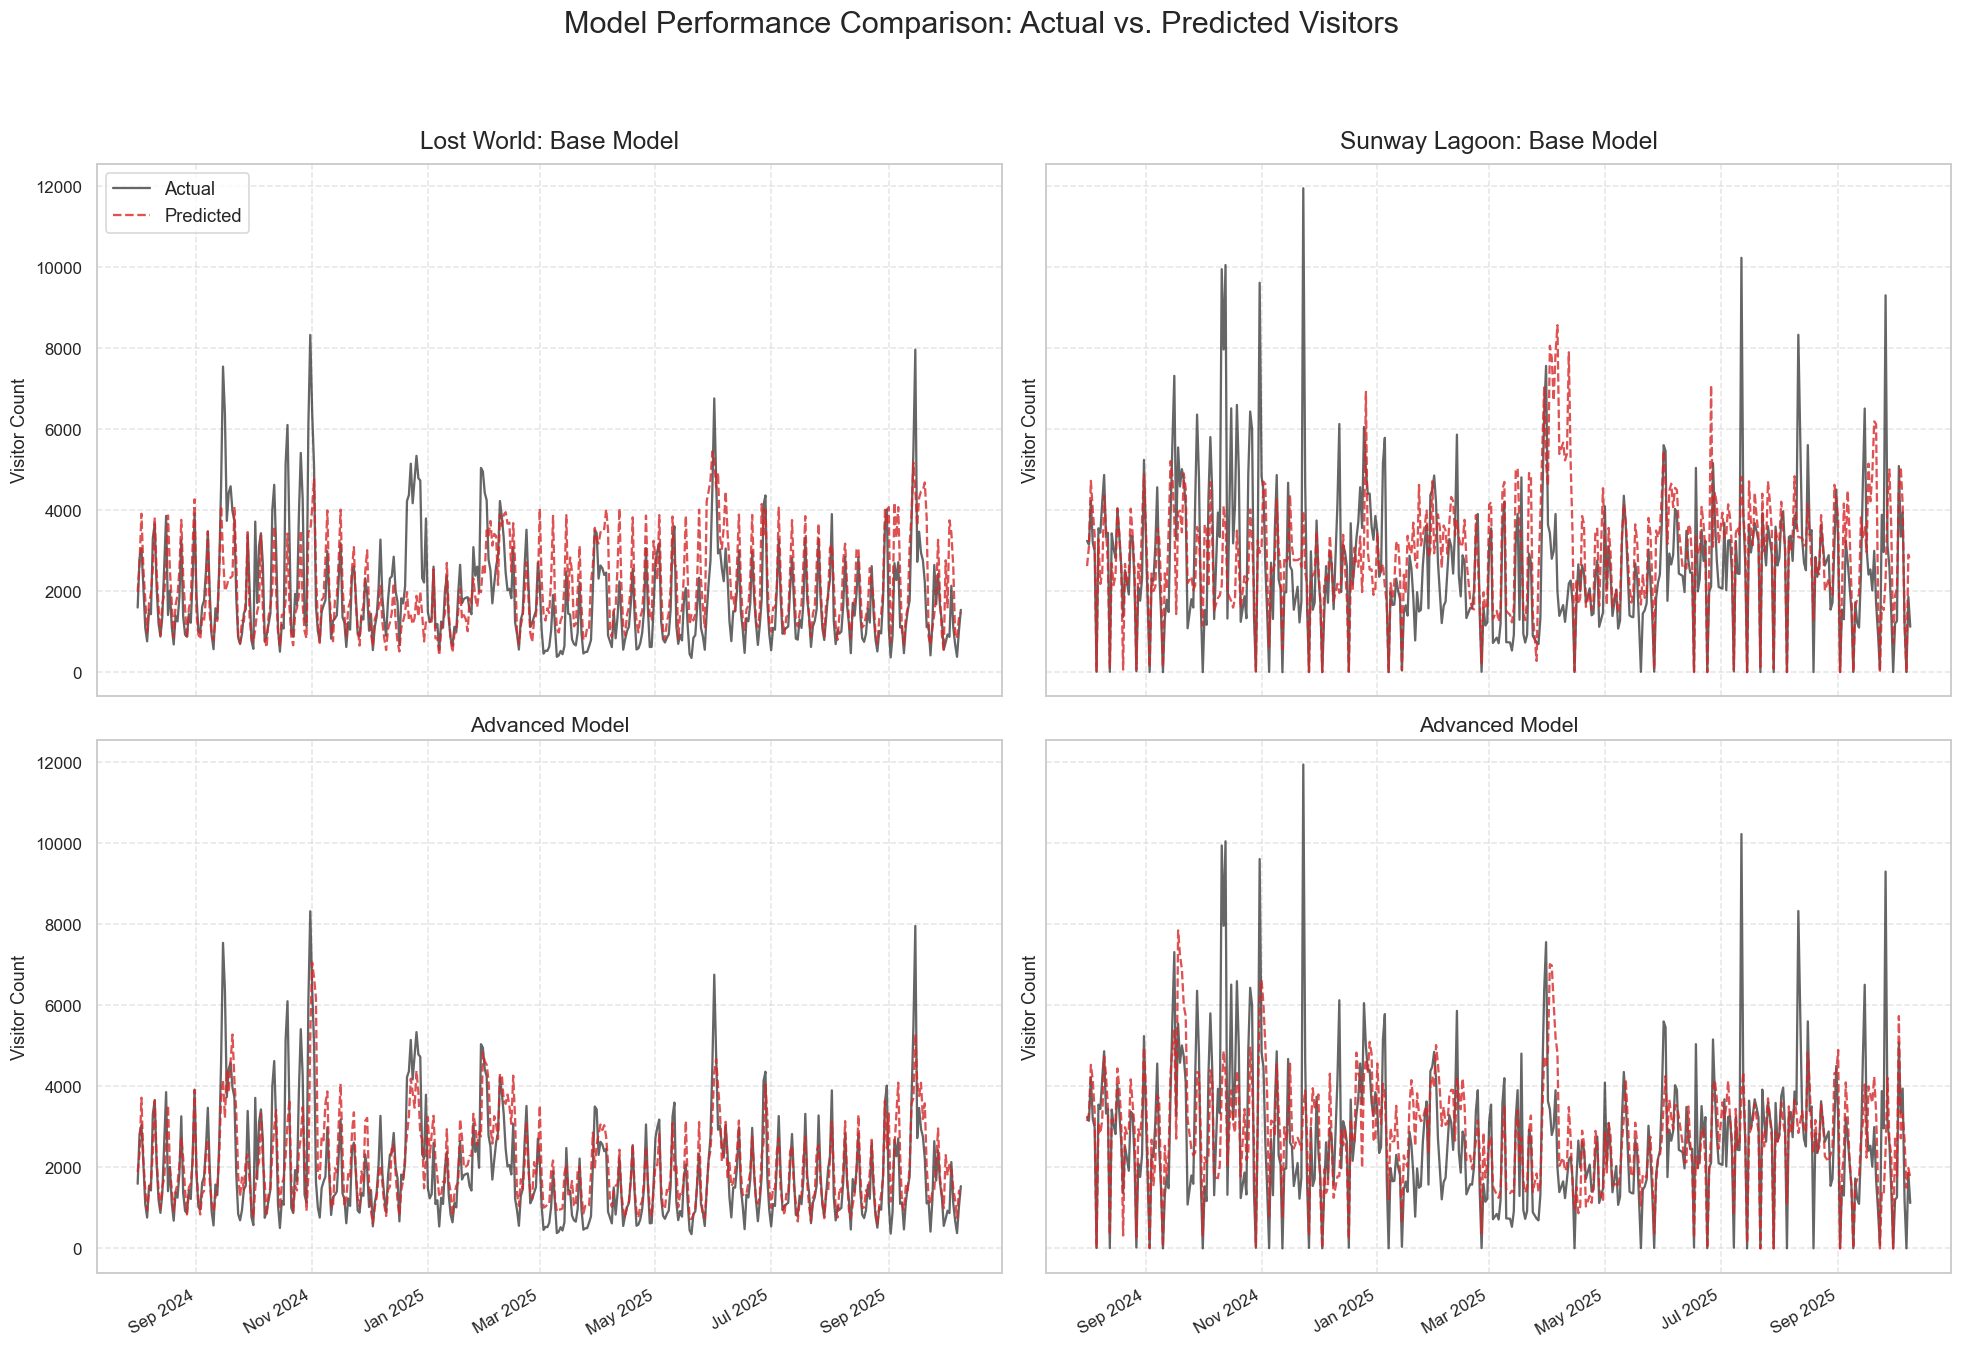

In [216]:
# Visualize the prediction VS actual result
# 1. Combine all predictions into one DataFrame
all_predictions_df = pd.concat(all_predictions_list)
all_predictions_df['visit_date'] = pd.to_datetime(all_predictions_df['visit_date'])

# 2. Setup the 2x2 Grid
# We define our iterators: Model Types and Parks
model_types = ['Base Model', 'Advanced Model']
parks = all_predictions_df['park'].unique()

# Create subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey='row')
fig.suptitle('Model Performance Comparison: Actual vs. Predicted Visitors', fontsize=20, y=1.02)

# 3. Iterate through Grid Positions
plot_count = 0
for row, m_type in enumerate(model_types):
    for col, p_name in enumerate(parks):
        ax = axes[row, col]
        
        # Filter data for this specific plot (this park + this model)
        plot_data = all_predictions_df[
            (all_predictions_df['model_type'] == m_type) & 
            (all_predictions_df['park'] == p_name)
        ].sort_values('visit_date')
        
        # Plot Actual vs. Predicted
        ax.plot(plot_data['visit_date'], plot_data[target], label='Actual', color='black', alpha=0.6, linewidth=1.5)
        ax.plot(plot_data['visit_date'], plot_data['prediction'], label='Predicted', color='tab:red', linestyle='--', alpha=0.8, linewidth=1.5)
        
        # Chart Formatting
        if row == 0:
            ax.set_title(f'{p_name}: {m_type}', fontsize=16, pad=10)
        else:
            ax.set_title(f'{m_type}', fontsize=14)
            
        ax.set_ylabel('Visitor Count', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Only show legend on the first plot to avoid clutter
        if plot_count == 0:
            ax.legend(fontsize=12, loc='upper left')
        
        plot_count += 1

# 4. Final Layout Adjustments
# Format the x-axis to show months clearly
for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # Tick every 2 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # Format: 'Jan 2024'
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right') # Rotate labels

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to fit main title
plt.show()

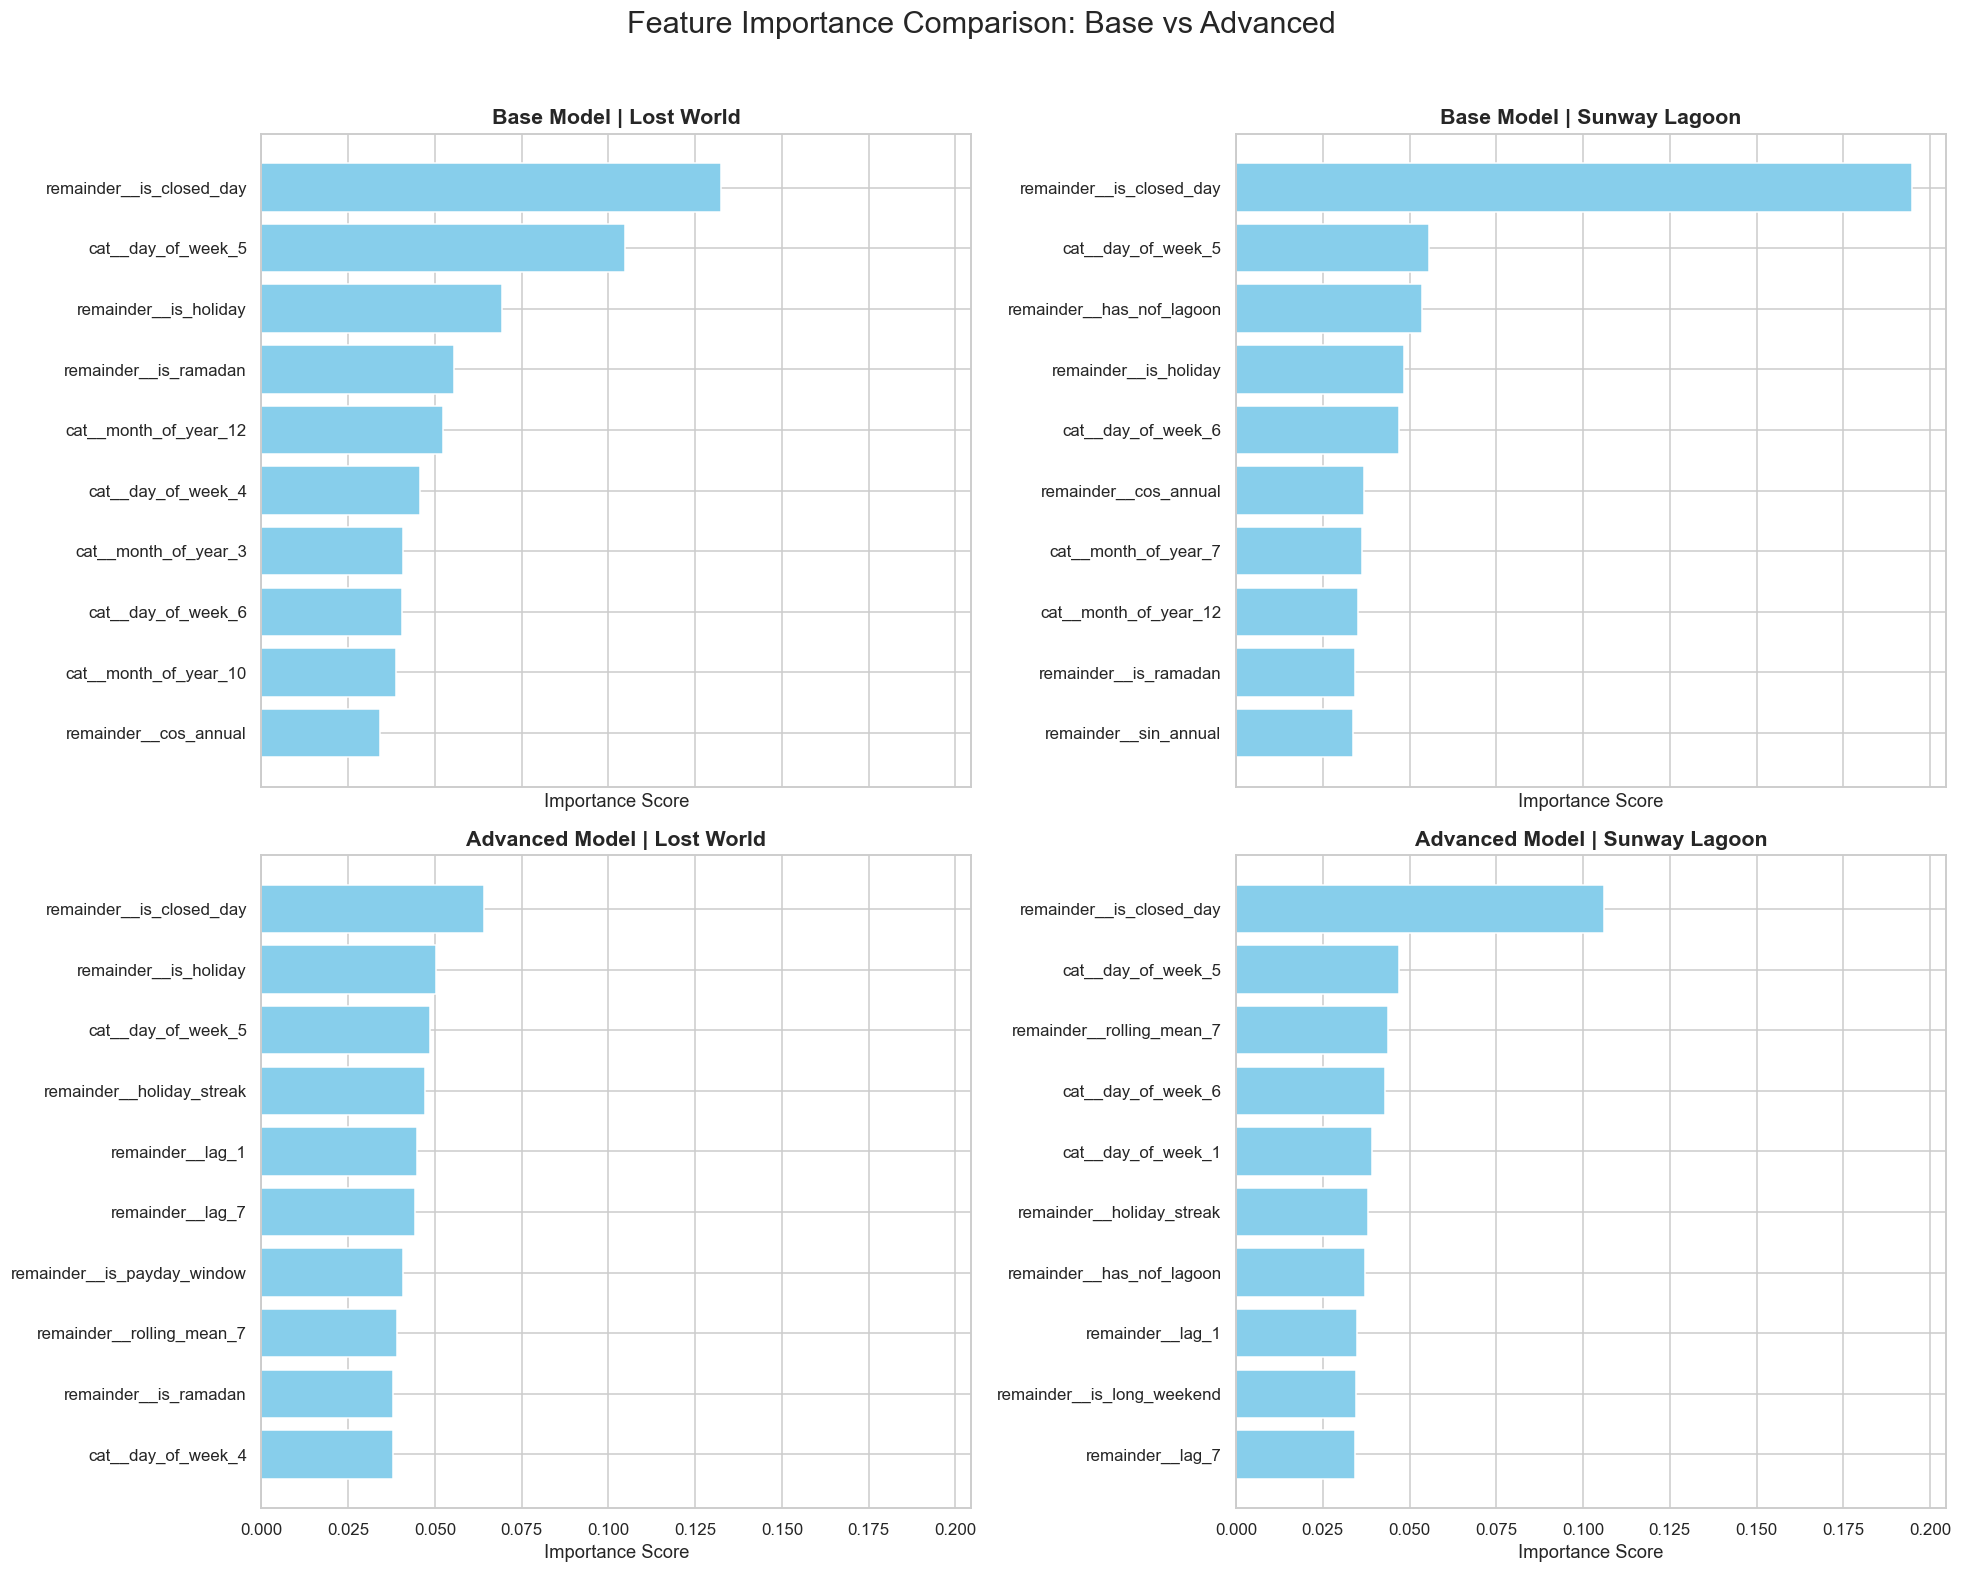

In [217]:
# Feature importance plot

# 1. Setup the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=True)
fig.suptitle('Feature Importance Comparison: Base vs Advanced', fontsize=20, y=1.02)

# Define the grid structure (Row 0 = Base, Row 1 = Advanced)
model_types = ['Base Model', 'Advanced Model']
parks = sorted(dat['park'].unique()) # Ensures order (e.g., Lost World, Sunway)

for row, m_type in enumerate(model_types):
    for col, p in enumerate(parks):
        ax = axes[row, col]
        
        # Get data from the dictionary
        key = (m_type, p)
        if key in final_importances:
            df = final_importances[key].head(10) # Top 10 features
            ax.barh(df['Feature'], df['Importance'], color='skyblue')
            ax.set_title(f"{m_type} | {p}", fontsize=14, fontweight='bold')
            ax.invert_yaxis()
            ax.set_xlabel("Importance Score")
        else:
            ax.text(0.5, 0.5, 'No data', ha='center')

plt.tight_layout()
plt.show()